# TDW6323 Data Wrangling and Visualisation — Lab Assignment

**Group Number:** [Group_XX]

**Group Members:**
- A. [Student ID] [Name]
- B. [Student ID] [Name]
- C. [Student ID] [Name]
- D. [Student ID] [Name]

**Dataset:** `Diabetic_Data.csv`

**Submission Deadline:** 15 June 2026, 10:00 AM


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Notebook display settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = Path("dataset/diabetic_data.csv")

---
# Part 1 — Data Cleaning and Transformation (10 Marks)

We work with `Diabetic_Data.csv`, a real-world healthcare dataset from the UCI repository.
The dataset records diabetic patient encounters and contains a mix of missing values,
categorical drug dosage columns, and ICD-9 diagnosis codes that require transformation
before any analysis or modelling can be performed.


## 1. Missing Data Handling (4 Marks)


### 1.1 Display and describe the dataset

We load the CSV and immediately replace the sentinel value `?` with `NaN` so that all
missing-value operations work consistently.


In [2]:
# '?' is used throughout the raw CSV to represent unknown/missing values
df = pd.read_csv(DATA_PATH, na_values="?", low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names ({len(df.columns)}):")
print(df.columns.tolist())

Shape: 101,766 rows x 50 columns

Column names (50):
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [3]:
# Preview of the first few records
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Statistical summary of numerical columns
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
# Data types per column
print(df.dtypes.to_string())

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

### 1.2 Inspect shape and missing values

We count missing values per column and express them as a percentage of total rows
to decide on the appropriate treatment strategy for each column.


In [6]:
total_missing = df.isnull().sum()
pct_missing   = (total_missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": total_missing,
    "Missing %":     pct_missing,
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("=== Missing Value Audit ===")
display(missing_summary)

=== Missing Value Audit ===


,Missing Count,Missing %
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


**Imputation strategy decisions:**

| Column | Missing % | Strategy | Reason |
|---|---|---|---|
| `weight` | ~97% | **Drop column** | Imputing ~97% would fabricate data |
| `medical_specialty` | ~49% | **Drop column** | Too sparse; minimal signal for readmission |
| `payer_code` | ~40% | **Drop column** | Administrative; not predictive |
| `encounter_id`, `patient_nbr` | 0% | **Drop column** | Pure IDs — no predictive value |
| `race` | ~2.2% | **Mode imputation** | Small fraction; categorical column |
| `diag_1/2/3` | <2% | **Fill with -1** | Maps to 'NAN' category in ICD-9 categoriser |
| `A1Cresult`, `max_glu_serum` | ~83–95% | **Encode to -99** | Absence of test is meaningful; handled in Section 2 |


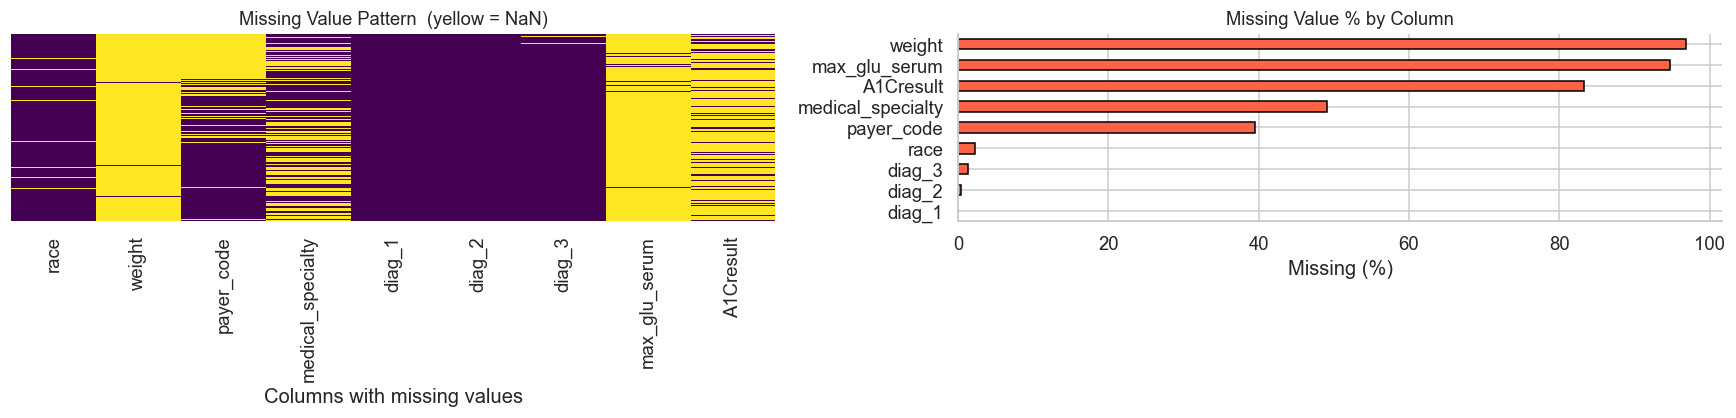

In [7]:
# Visualise the missing value pattern as a boolean heatmap
missing_cols = df.columns[df.isnull().any()].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Heatmap — yellow cell = NaN
sns.heatmap(df[missing_cols].isnull(), yticklabels=False,
            cbar=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Missing Value Pattern  (yellow = NaN)", fontsize=12)
axes[0].set_xlabel("Columns with missing values")

# Bar chart — missing percentage
missing_summary["Missing %"].plot(kind="barh", ax=axes[1],
                                   color="tomato", edgecolor="black")
axes[1].set_xlabel("Missing (%)")
axes[1].set_title("Missing Value % by Column", fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Observation:** `weight`, `medical_specialty`, and `payer_code` have extremely high
missing rates (40–97%), making imputation unreliable. They are dropped. `race` has
only ~2.2% missing and is safely imputed with the most frequent category (Caucasian).
Diagnosis columns (`diag_1/2/3`) have under 2% missing and are filled with `-1`, which
the downstream ICD-9 categoriser maps to 'NAN'.


### 1.3 Transform 'readmitted' and refine NaN values


In [8]:
# Inspect the readmitted column before transformation
print("Unique values in 'readmitted':", df["readmitted"].unique().tolist())
print("Value counts:")
print(df["readmitted"].value_counts())

Unique values in 'readmitted': ['NO', '>30', '<30']
Value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


### 1.4 Drop non-impactful columns and impute remaining missing values


In [9]:
# Columns to drop — either administrative IDs or >40% missing
NON_IMPACTFUL_COLS = ["encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty"]
df.drop(columns=NON_IMPACTFUL_COLS, inplace=True, errors="ignore")
print(f"Dropped {len(NON_IMPACTFUL_COLS)} columns. Remaining: {df.shape[1]} columns")

Dropped 5 columns. Remaining: 45 columns


In [10]:
# Impute 'race' with mode — only ~2.2% missing, safe to fill with most frequent value
race_mode = df["race"].mode()[0]
n_race_missing = df["race"].isnull().sum()
df["race"] = df["race"].fillna(race_mode)
print(f"Imputed {n_race_missing:,} missing 'race' values with mode: '{race_mode}'")

Imputed 2,273 missing 'race' values with mode: 'Caucasian'


In [11]:
# Fill missing diagnosis codes with '-1' — the ICD-9 categoriser maps -1 to 'NAN'
for col in ["diag_1", "diag_2", "diag_3"]:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna("-1")
    print(f"Filled {n:,} missing values in '{col}' with '-1'")

Filled 21 missing values in 'diag_1' with '-1'
Filled 358 missing values in 'diag_2' with '-1'
Filled 1,423 missing values in 'diag_3' with '-1'


### 1.5 Split numerical and non-numerical attributes


In [12]:
# A1Cresult and max_glu_serum are excluded here — their NaN values are meaningful
# ('test not conducted') and will be encoded to -99 in Section 2
df_numerical   = df.select_dtypes(include="number")
df_categorical = df.select_dtypes(exclude="number")

print(f"Numerical columns   ({len(df_numerical.columns)}): {df_numerical.columns.tolist()}")
print(f"\nCategorical columns ({len(df_categorical.columns)}): {df_categorical.columns.tolist()}")

Numerical columns   (11): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns (34): ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


### 1.6 Verify all missing values are resolved


In [13]:
# Exclude A1Cresult and max_glu_serum — intentionally deferred to Section 2
DEFERRED = {"A1Cresult", "max_glu_serum"}
check_cols = [c for c in df.columns if c not in DEFERRED]

remaining = df[check_cols].isnull().sum()
still_missing = remaining[remaining > 0]

if still_missing.empty:
    print("All imputable missing values resolved.")
    print("(A1Cresult and max_glu_serum NaN are handled in Section 2 - encoded to -99)")
else:
    print("WARNING: Remaining missing values:")
    print(still_missing)

print(f"\nDataset shape after Section 1: {df.shape}")

All imputable missing values resolved.
(A1Cresult and max_glu_serum NaN are handled in Section 2 - encoded to -99)

Dataset shape after Section 1: (101766, 45)


---
## 2. Data Cleaning and Transformation (3 Marks)


### 2.1 Transform target variable and plot class distribution

`readmitted` is mapped to binary: any readmission event (`<30` or `>30` days) → **1**,
no readmission (`NO`) → **0**. Both timing variants are grouped as readmitted because
the assignment treats any return visit as the positive outcome.


In [14]:
READMITTED_MAP = {"NO": 0, "<30": 1, ">30": 1}

df["readmitted"] = df["readmitted"].map(READMITTED_MAP)

# Drop rows with unmappable values (edge-case guard)
df.dropna(subset=["readmitted"], inplace=True)
df["readmitted"] = df["readmitted"].astype(int)

print("Readmitted value counts:")
print(df["readmitted"].value_counts())
print(f"\nReadmission rate: {df['readmitted'].mean()*100:.1f}%")

Readmitted value counts:
readmitted
0    54864
1    46902
Name: count, dtype: int64

Readmission rate: 46.1%


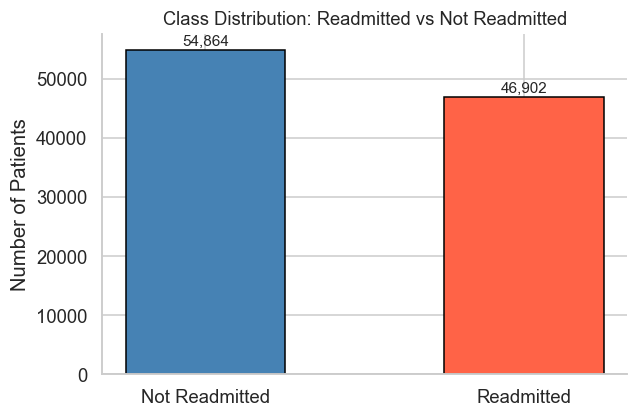

In [15]:
label_map = {0: "Not Readmitted", 1: "Readmitted"}
counts = df["readmitted"].map(label_map).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=["steelblue", "tomato"], edgecolor="black", width=0.5)
ax.set_title("Class Distribution: Readmitted vs Not Readmitted", fontsize=12)
ax.set_ylabel("Number of Patients")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

**Explanation:** The dataset is relatively balanced — 46,902 readmitted (~46%) vs
54,864 not readmitted (~54%). This means we do not need to apply class balancing
techniques (e.g. SMOTE) for feature selection or visualisation in this assignment.


### 2.2 Impact of gender, age, and race on readmission

We plot **readmission rate** (%) per demographic group rather than raw counts
to correct for unequal group sizes (e.g. far fewer 0–10 year olds than 50–60 year olds).


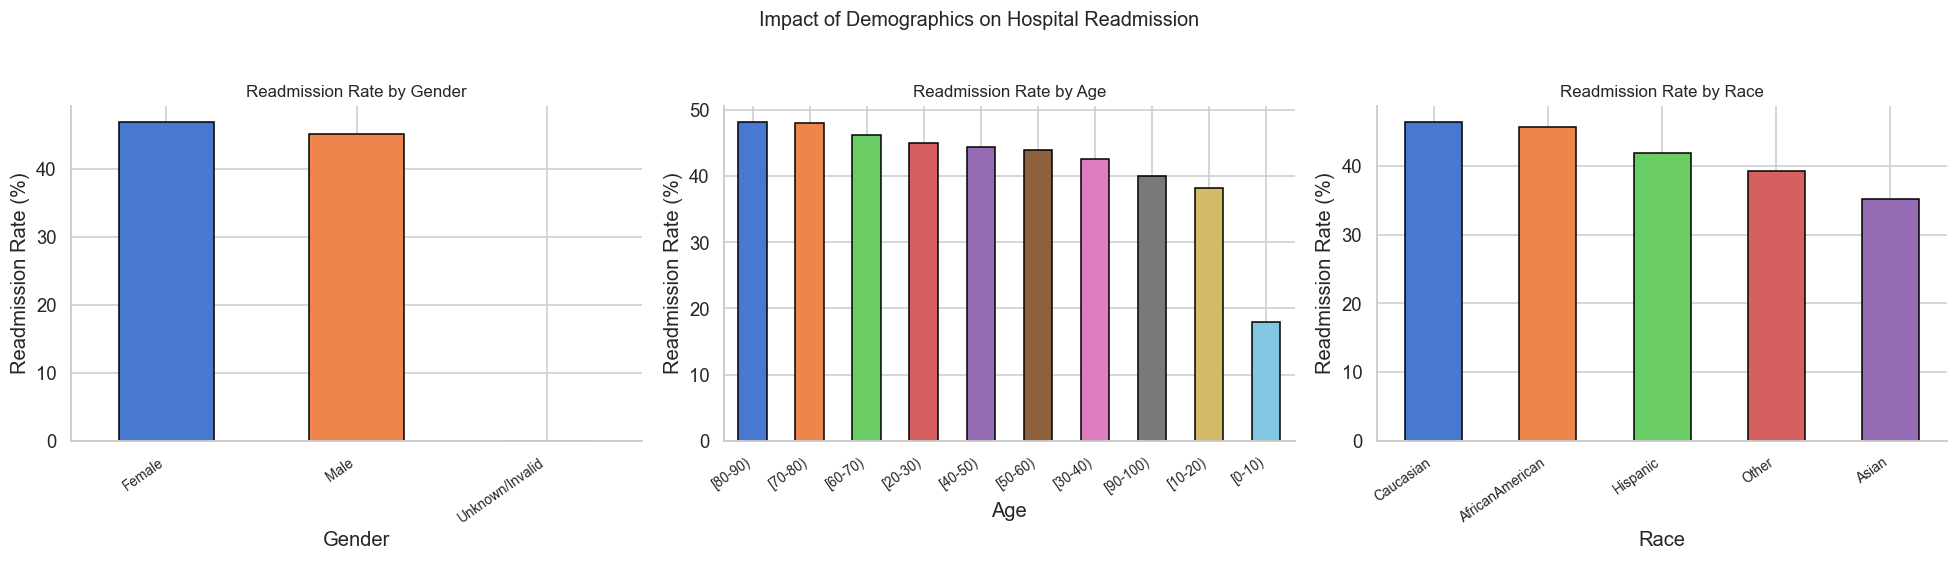

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

demo_cols = ["gender", "age", "race"]

for ax, col in zip(axes, demo_cols):
    rate = (df.groupby(col)["readmitted"]
              .mean()
              .mul(100)
              .sort_values(ascending=False))
    bars = rate.plot(kind="bar", ax=ax,
                     color=sns.color_palette("muted"), edgecolor="black")
    ax.set_title(f"Readmission Rate by {col.capitalize()}", fontsize=11)
    ax.set_ylabel("Readmission Rate (%)")
    ax.set_xlabel(col.capitalize())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)

fig.suptitle("Impact of Demographics on Hospital Readmission", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Explanation:**
- **Gender:** Male and female patients show similar readmission rates. The 'Unknown/Invalid'
  category is negligible in count.
- **Age:** Readmission rates are highest in the 70–90 age groups, consistent with medical
  literature — elderly patients with diabetes have more comorbidities and slower recovery.
- **Race:** Readmission rates are broadly similar across racial groups, with slight variation
  that may reflect systemic differences in healthcare access rather than biological factors.


### 2.3 Insulin intake impact on readmitted patients


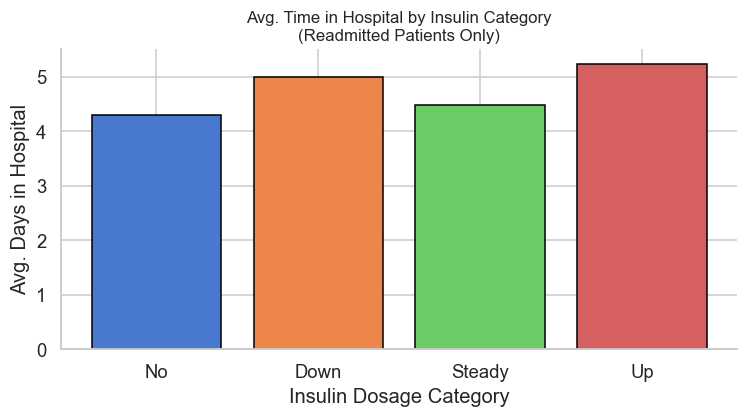

In [17]:
INSULIN_ORDER = ["No", "Down", "Steady", "Up"]
readmitted_df = df[df["readmitted"] == 1].copy()
readmitted_df["insulin"] = pd.Categorical(readmitted_df["insulin"],
                                           categories=INSULIN_ORDER, ordered=True)

# Summary: average time in hospital per insulin category (readmitted patients only)
avg_insulin = (readmitted_df.groupby("insulin", observed=True)["time_in_hospital"]
                             .mean()
                             .reset_index())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(avg_insulin["insulin"].astype(str),
       avg_insulin["time_in_hospital"],
       color=sns.color_palette("muted", 4), edgecolor="black")
ax.set_title("Avg. Time in Hospital by Insulin Category\n(Readmitted Patients Only)", fontsize=11)
ax.set_xlabel("Insulin Dosage Category")
ax.set_ylabel("Avg. Days in Hospital")
plt.tight_layout()
plt.show()

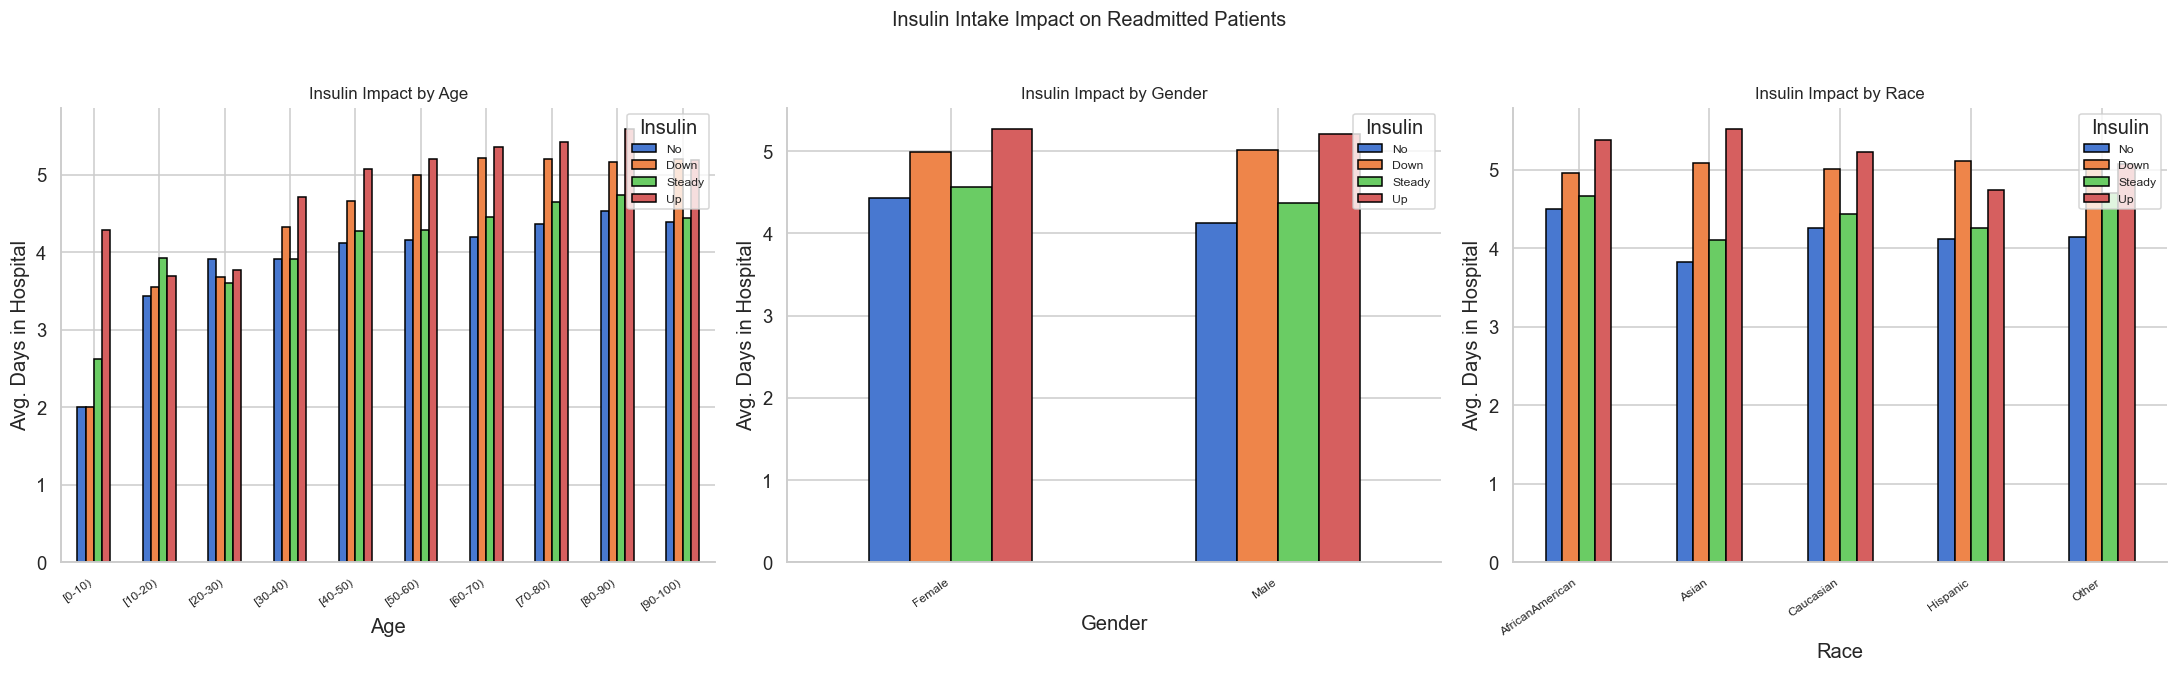

In [18]:
# Breakdown by age group, gender, and race
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, ["age", "gender", "race"]):
    pivot = (readmitted_df.groupby([col, "insulin"], observed=True)["time_in_hospital"]
                          .mean()
                          .unstack("insulin"))
    pivot.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"Insulin Impact by {col.capitalize()}", fontsize=11)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Avg. Days in Hospital")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    ax.legend(title="Insulin", fontsize=8, loc="upper right")

fig.suptitle("Insulin Intake Impact on Readmitted Patients", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Explanation:**
- Patients on 'Steady' or 'Up' insulin dosages tend to have slightly longer hospital stays,
  suggesting more severe or complex diabetic conditions requiring active insulin management.
- Across age groups, older patients (70–90) with active insulin ('Steady'/'Up') consistently
  show longer stays, reinforcing that age amplifies the effect of diabetic severity.
- Gender breakdown shows minimal difference in the insulin–stay relationship.
- The 'Down' category (dosage reduced during stay) is associated with shorter stays,
  possibly indicating improving condition.


### 2.4 Clean and categorise diagnosis columns (diag_1, diag_2, diag_3)

ICD-9 numeric codes are mapped to 10 disease categories using the ranges specified
in the assignment. Non-numeric codes (V-codes, E-codes) fall into 'Other'.


In [19]:
def map_icd9_to_category(raw_value: object) -> str:
    """Map a single ICD-9 code to a disease category string."""
    try:
        v = int(float(str(raw_value)))
    except (ValueError, TypeError):
        return "Other"

    if v == -1:                           return "NAN"
    if (390 <= v <= 459) or v == 785:     return "Circulatory"
    if (460 <= v <= 519) or v == 786:     return "Respiratory"
    if (520 <= v <= 579) or v == 787:     return "Digestive"
    if v == 250:                          return "Diabetes"
    if 800 <= v <= 999:                   return "Injury"
    if 710 <= v <= 739:                   return "Musculoskeletal"
    if (580 <= v <= 629) or v == 788:     return "Genitourinary"
    if 140 <= v <= 239:                   return "Neoplasms"
    return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].fillna("-1").apply(map_icd9_to_category)

print("Diagnosis category mapping complete.")
print("\ndiag_1 value counts:")
print(df["diag_1"].value_counts())

Diagnosis category mapping complete.

diag_1 value counts:
diag_1
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
NAN                   21
Name: count, dtype: int64


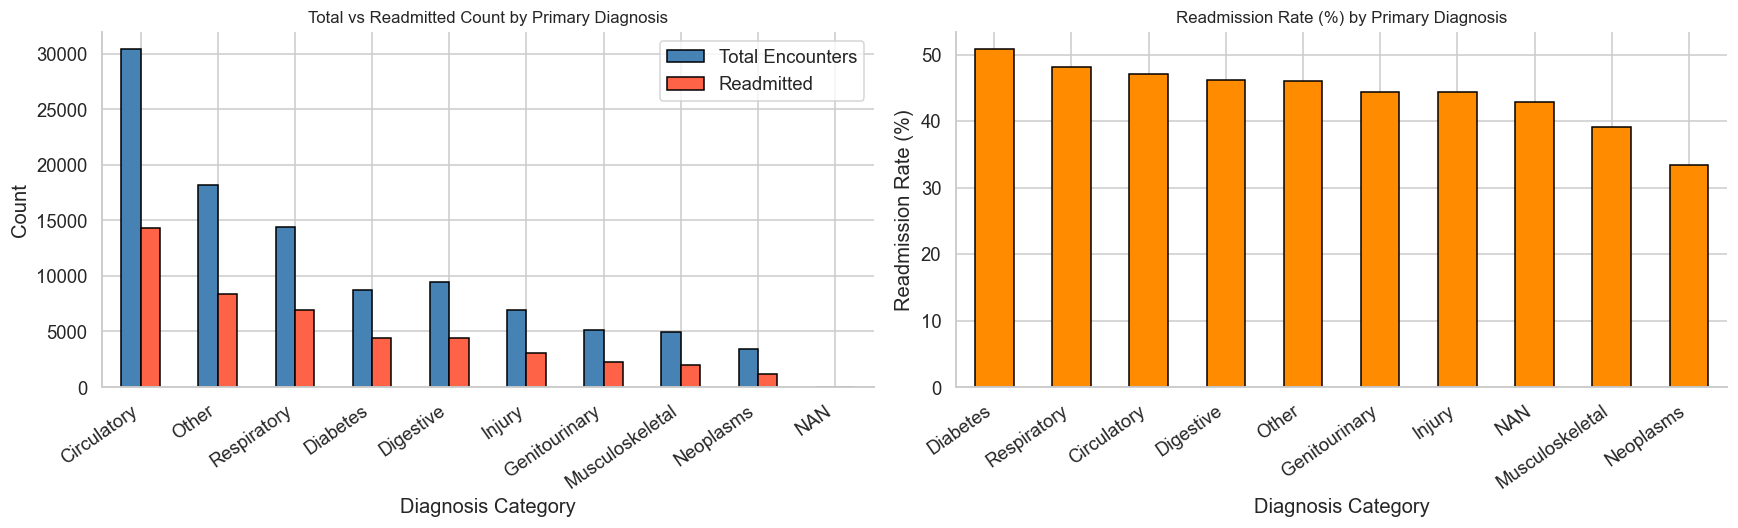

Most readmitted primary diagnosis category: 'Circulatory' (14,324 cases)


In [20]:
# Plot readmission count by primary diagnosis category
diag_summary = (df.groupby("diag_1")["readmitted"]
                  .agg(total="count", readmitted_count="sum")
                  .sort_values("readmitted_count", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total vs readmitted count
diag_summary[["total", "readmitted_count"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black"
)
axes[0].set_title("Total vs Readmitted Count by Primary Diagnosis", fontsize=11)
axes[0].set_xlabel("Diagnosis Category")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")
axes[0].legend(["Total Encounters", "Readmitted"])

# Readmission rate per category
readmit_rate = (diag_summary["readmitted_count"] / diag_summary["total"] * 100).sort_values(ascending=False)
readmit_rate.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_title("Readmission Rate (%) by Primary Diagnosis", fontsize=11)
axes[1].set_xlabel("Diagnosis Category")
axes[1].set_ylabel("Readmission Rate (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.show()

top_cat = diag_summary["readmitted_count"].idxmax()
print(f"Most readmitted primary diagnosis category: '{top_cat}' "
      f"({int(diag_summary.loc[top_cat, 'readmitted_count']):,} cases)")

**Explanation:** The **Circulatory** system category (ICD-9 codes 390–459, 785) is the
most readmitted primary diagnosis — this is expected as cardiovascular complications are
the leading comorbidity in diabetic patients. **Other** and **Diabetes** categories also
show high readmission counts. The readmission *rate* chart reveals that Circulatory
patients have among the highest rates, confirming this is both common and difficult to
prevent in a single hospitalisation.


### 2.5 Encode drug feature columns

21 drug columns are encoded to binary integers:
`'No'` → **0** (drug not prescribed/active),
`'Steady'`, `'Up'`, `'Down'` → **1** (drug is actively used in some form).


In [21]:
DRUG_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone",
]

DRUG_MAP = {"No": 0, "Steady": 1, "Up": 1, "Down": 1}

for col in DRUG_COLS:
    if col in df.columns:
        df[col] = df[col].map(DRUG_MAP).astype(int)

print(f"Encoded {len(DRUG_COLS)} drug columns to binary int.")
print("\nSample — insulin column value counts after encoding:")
print(df["insulin"].value_counts())

Encoded 23 drug columns to binary int.

Sample — insulin column value counts after encoding:
insulin
1    54383
0    47383
Name: count, dtype: int64


### 2.6 Encode A1Cresult and max_glu_serum

Lab test results are encoded to integers. NaN (test not conducted) → **-99**, which
preserves the column as integer dtype and lets downstream code identify untested patients.


In [22]:
A1C_MAP = {">7": 1, ">8": 1, "Norm": 0, "None": -99}
GLU_MAP = {">200": 1, ">300": 1, "Norm": 0, "None": -99}

df["A1Cresult"]     = df["A1Cresult"].map(A1C_MAP).fillna(-99).astype(int)
df["max_glu_serum"] = df["max_glu_serum"].map(GLU_MAP).fillna(-99).astype(int)

print("A1Cresult value counts:")
print(df["A1Cresult"].value_counts())
print("\nmax_glu_serum value counts:")
print(df["max_glu_serum"].value_counts())
print(f"\nDataset shape after Section 2: {df.shape}")

A1Cresult value counts:
A1Cresult
-99    84748
 1     12028
 0      4990
Name: count, dtype: int64

max_glu_serum value counts:
max_glu_serum
-99    96420
 1      2749
 0      2597
Name: count, dtype: int64

Dataset shape after Section 2: (101766, 45)


---
## 3. Outlier Detection and Treatment (3 Marks)

**Method chosen: Interquartile Range (IQR)**
**Treatment: Winsorisation (clipping to [Q1 − 1.5·IQR, Q3 + 1.5·IQR])**

**Why IQR over alternatives:**
- The numeric columns are right-skewed (e.g. `number_outpatient` has a long tail of repeat
  visitors), which causes Z-Score to under-detect outliers in skewed distributions.
- DBSCAN requires distance-matrix computation on 100k rows and hyperparameter tuning
  (`epsilon`, `min_samples`) — impractical without domain guidance.
- IQR is non-parametric, robust, and well-understood by healthcare analysts.

**Why Winsorisation over row removal:**
- Removing rows with outliers would lose up to 16,739 outpatient records in a single column,
  discarding legitimate high-utilisation patients that are medically informative.
- Winsorisation retains all 101,766 rows while capping the influence of extreme values
  on statistics and model training.


### 3.1 Explore potential outliers with box plots and scatter plot


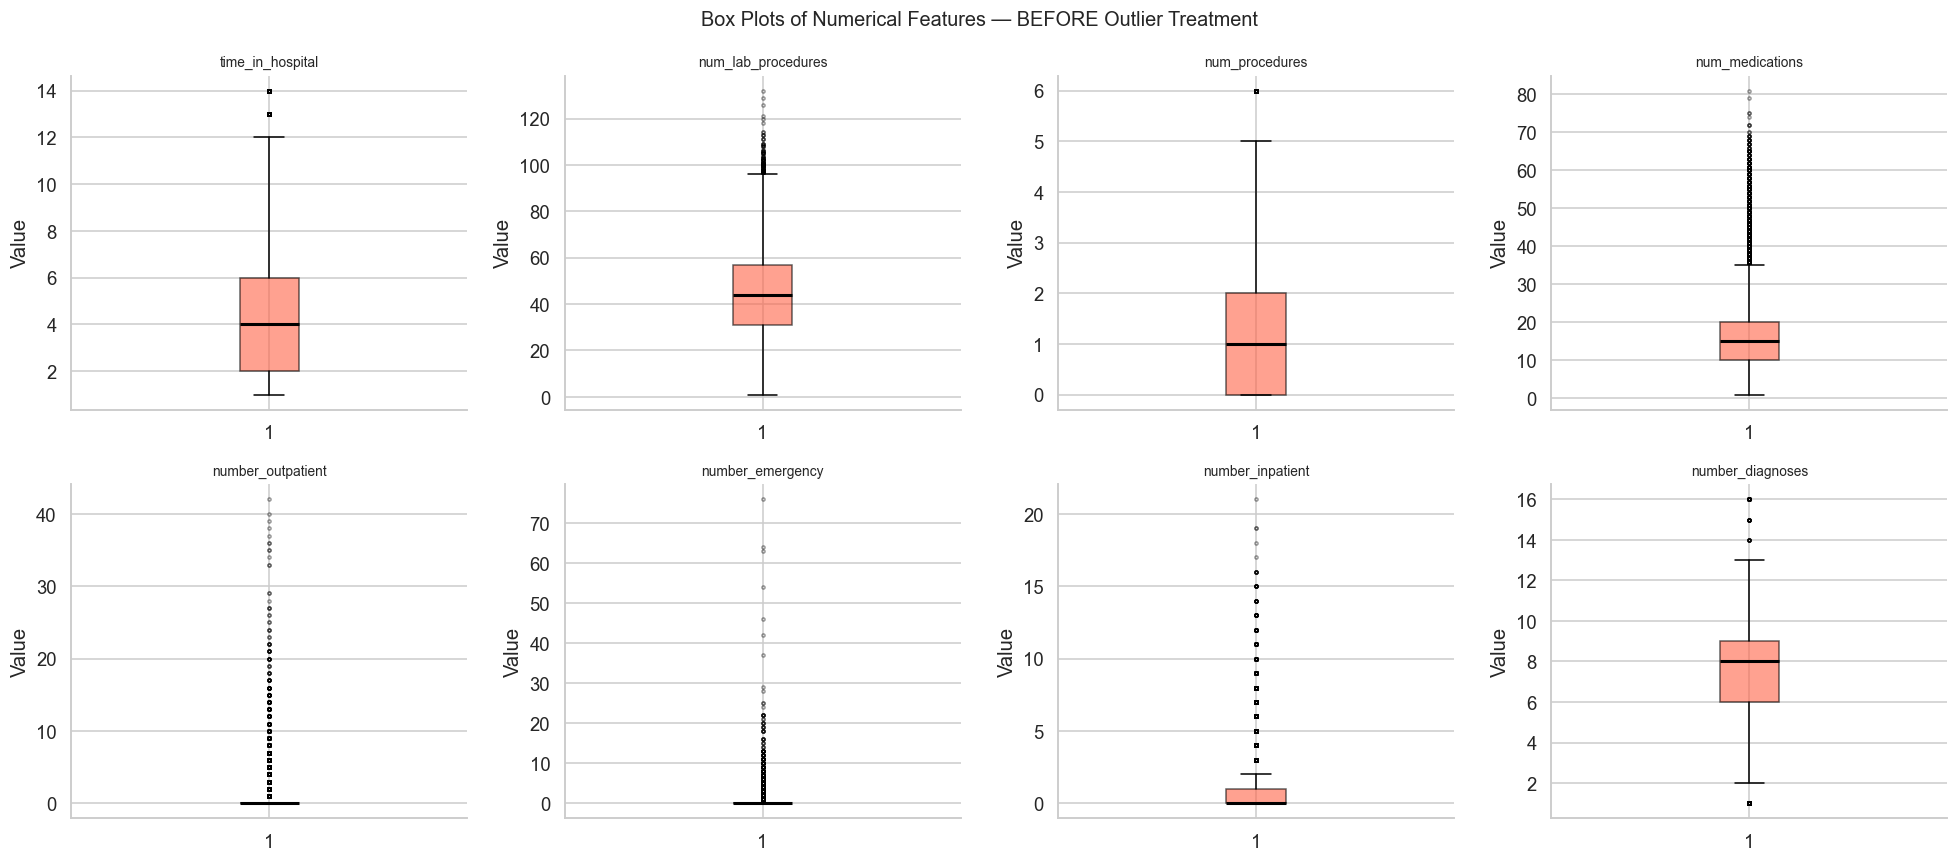

In [23]:
NUMERICAL_COLS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

# Box plots — BEFORE treatment
n = len(NUMERICAL_COLS)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, NUMERICAL_COLS):
    ax.boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor="tomato", alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markersize=2, alpha=0.4, color="grey"),
    )
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Value")

fig.suptitle("Box Plots of Numerical Features — BEFORE Outlier Treatment", fontsize=13)
plt.tight_layout()
plt.show()

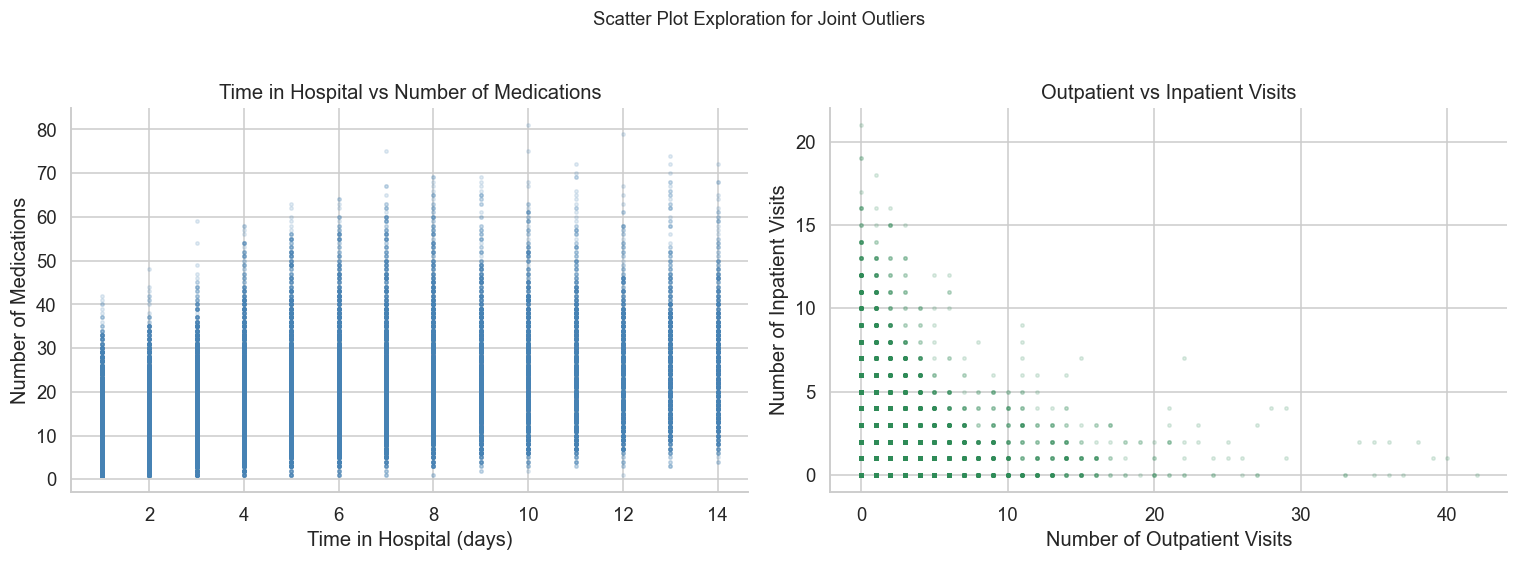

In [24]:
# Scatter plot: time_in_hospital vs num_medications
# Isolated points far from the dense cluster are potential joint outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["time_in_hospital"], df["num_medications"],
                alpha=0.15, s=5, color="steelblue")
axes[0].set_xlabel("Time in Hospital (days)")
axes[0].set_ylabel("Number of Medications")
axes[0].set_title("Time in Hospital vs Number of Medications")

axes[1].scatter(df["number_outpatient"], df["number_inpatient"],
                alpha=0.15, s=5, color="seagreen")
axes[1].set_xlabel("Number of Outpatient Visits")
axes[1].set_ylabel("Number of Inpatient Visits")
axes[1].set_title("Outpatient vs Inpatient Visits")

plt.suptitle("Scatter Plot Exploration for Joint Outliers", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Observation from box plots:** `number_outpatient` and `number_emergency` show very long
whiskers and many outlier points, indicating a small subset of patients with extremely high
visit frequencies. `num_lab_procedures` and `num_medications` also show some extreme values.
These will be identified and treated using IQR fences.


### 3.2 IQR outlier detection


In [25]:
# Compute IQR bounds for each column
iqr_stats = {}
for col in NUMERICAL_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    iqr_stats[col] = {
        "Q1":    q1,
        "Q3":    q3,
        "IQR":   iqr,
        "Lower Fence": q1 - 1.5 * iqr,
        "Upper Fence": q3 + 1.5 * iqr,
    }

bounds_df = pd.DataFrame(iqr_stats).T
print("=== IQR Bounds (1.5 x IQR fences) ===")
display(bounds_df.round(2))

=== IQR Bounds (1.5 x IQR fences) ===


,Q1,Q3,IQR,Lower Fence,Upper Fence
time_in_hospital,2.0,6.0,4.0,-4.0,12.0
num_lab_procedures,31.0,57.0,26.0,-8.0,96.0
num_procedures,0.0,2.0,2.0,-3.0,5.0
num_medications,10.0,20.0,10.0,-5.0,35.0
number_outpatient,0.0,0.0,0.0,0.0,0.0
number_emergency,0.0,0.0,0.0,0.0,0.0
number_inpatient,0.0,1.0,1.0,-1.5,2.5
number_diagnoses,6.0,9.0,3.0,1.5,13.5


In [26]:
# Count outliers per column (values outside the fences)
outlier_counts = {}
for col in NUMERICAL_COLS:
    lower = bounds_df.loc[col, "Lower Fence"]
    upper = bounds_df.loc[col, "Upper Fence"]
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = n_out

outlier_series = pd.Series(outlier_counts, name="Outlier Count")
print("=== Outlier Count per Column ===")
display(outlier_series.to_frame())
print(f"\nTotal outlier values across all columns: {outlier_series.sum():,}")

=== Outlier Count per Column ===


,Outlier Count
time_in_hospital,2252
num_lab_procedures,143
num_procedures,4954
num_medications,2557
number_outpatient,16739
number_emergency,11383
number_inpatient,7049
number_diagnoses,281



Total outlier values across all columns: 45,358


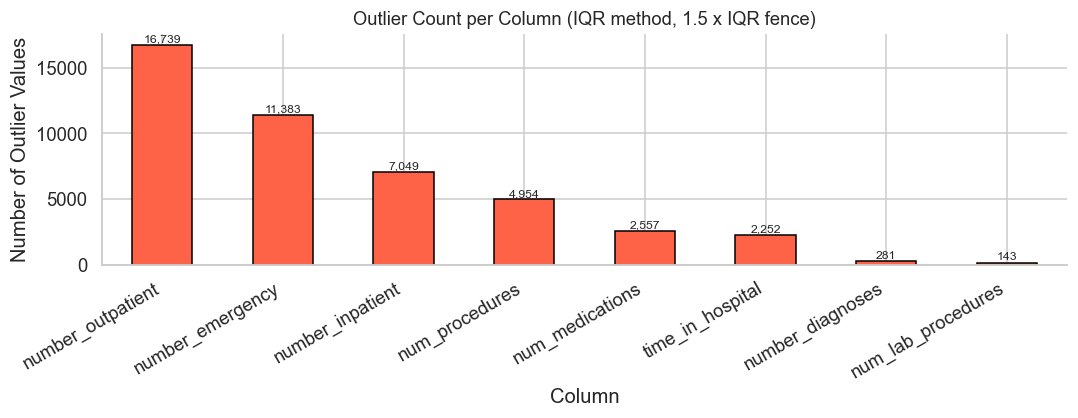

In [27]:
# Visualise outlier counts as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))
outlier_series.sort_values(ascending=False).plot(
    kind="bar", ax=ax, color="tomato", edgecolor="black"
)
ax.set_title("Outlier Count per Column (IQR method, 1.5 x IQR fence)", fontsize=12)
ax.set_ylabel("Number of Outlier Values")
ax.set_xlabel("Column")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

**Observation:** `number_outpatient` (16,739), `number_emergency` (11,383), and
`number_inpatient` (7,049) have the highest outlier counts. These represent high-utilisation
patients with many visits — a real clinical pattern but statistically extreme. `num_procedures`
(4,954) also has a large outlier count due to its right-skewed distribution.


### 3.3 Apply outlier treatment — Winsorisation (clipping)


In [28]:
# Snapshot before treatment for visual comparison
df_before = df[NUMERICAL_COLS].copy()

# Clip each column to its IQR fence boundaries
for col in NUMERICAL_COLS:
    lower = bounds_df.loc[col, "Lower Fence"]
    upper = bounds_df.loc[col, "Upper Fence"]
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Winsorisation applied.")
print(f"Dataset shape unchanged: {df.shape}")
print(f"Total NaN values remaining: {df.isnull().sum().sum()}")

Winsorisation applied.
Dataset shape unchanged: (101766, 45)
Total NaN values remaining: 0


### 3.4 Before vs After comparison


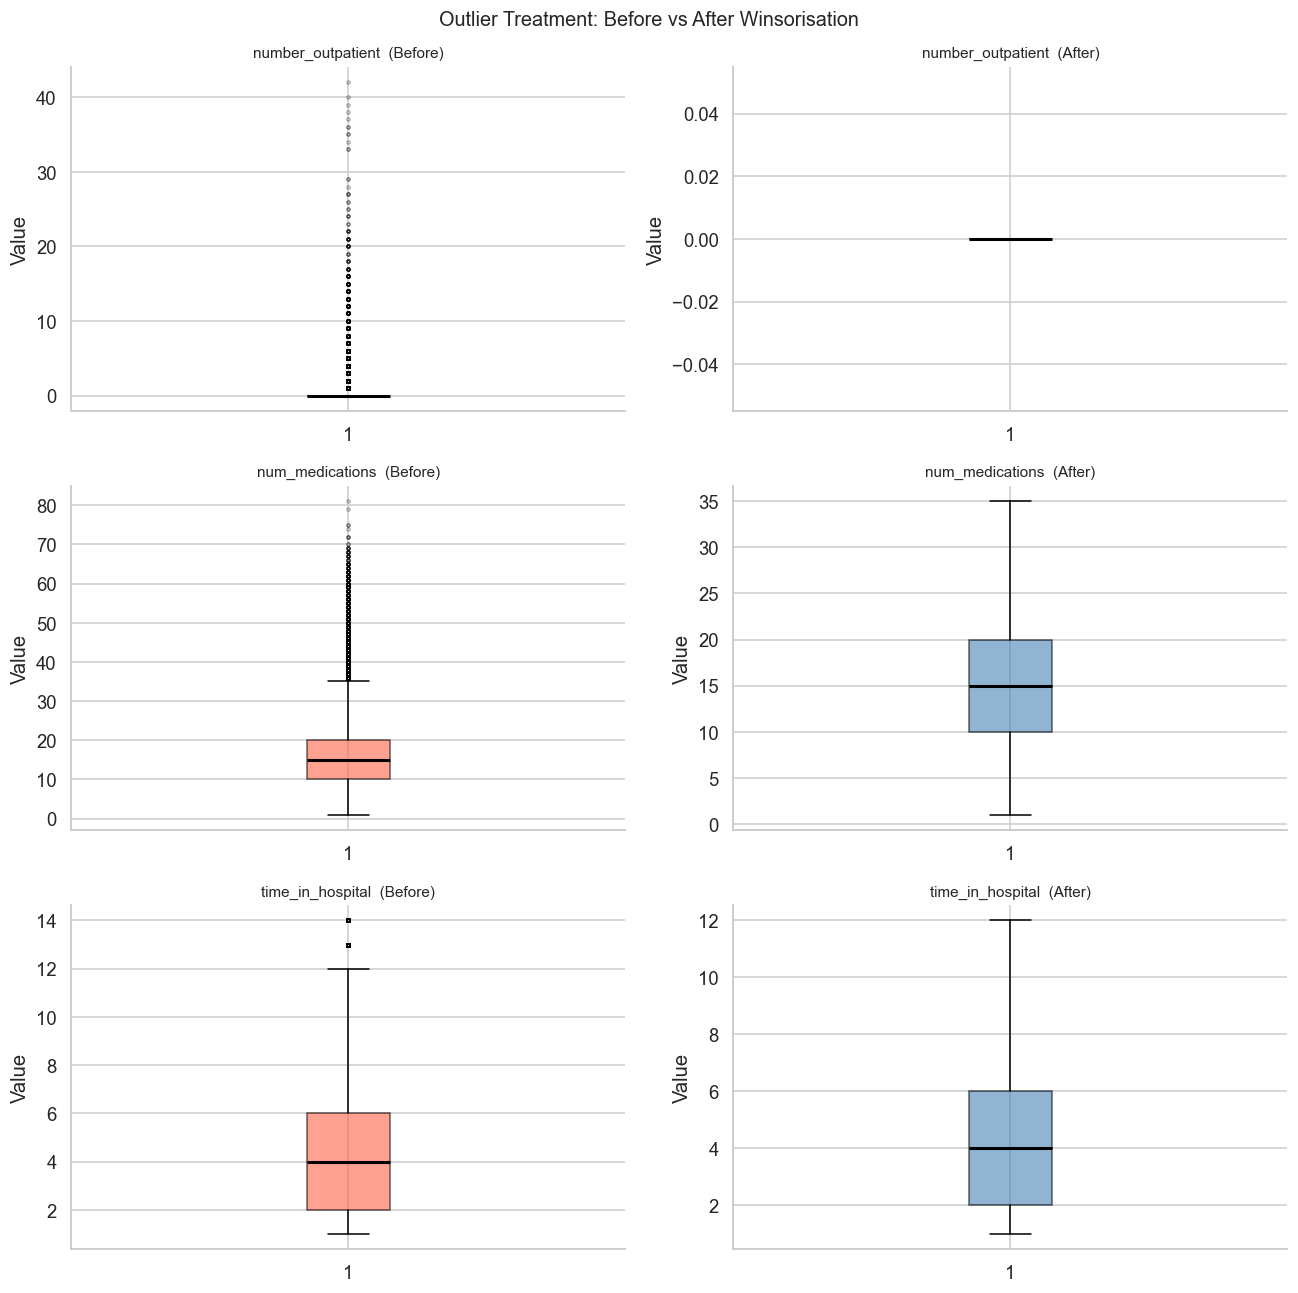

In [29]:
# Side-by-side box plots for three columns that had the most outliers
spotlight = ["number_outpatient", "num_medications", "time_in_hospital"]

fig, axes = plt.subplots(len(spotlight), 2, figsize=(12, 4 * len(spotlight)))

for i, col in enumerate(spotlight):
    for j, (label, data, color) in enumerate([
        ("Before", df_before[col], "tomato"),
        ("After",  df[col],        "steelblue"),
    ]):
        ax = axes[i][j]
        ax.boxplot(
            data.dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
            flierprops=dict(marker="o", markersize=2, alpha=0.3),
        )
        ax.set_title(f"{col}  ({label})", fontsize=10)
        ax.set_ylabel("Value")

fig.suptitle("Outlier Treatment: Before vs After Winsorisation", fontsize=13)
plt.tight_layout()
plt.show()

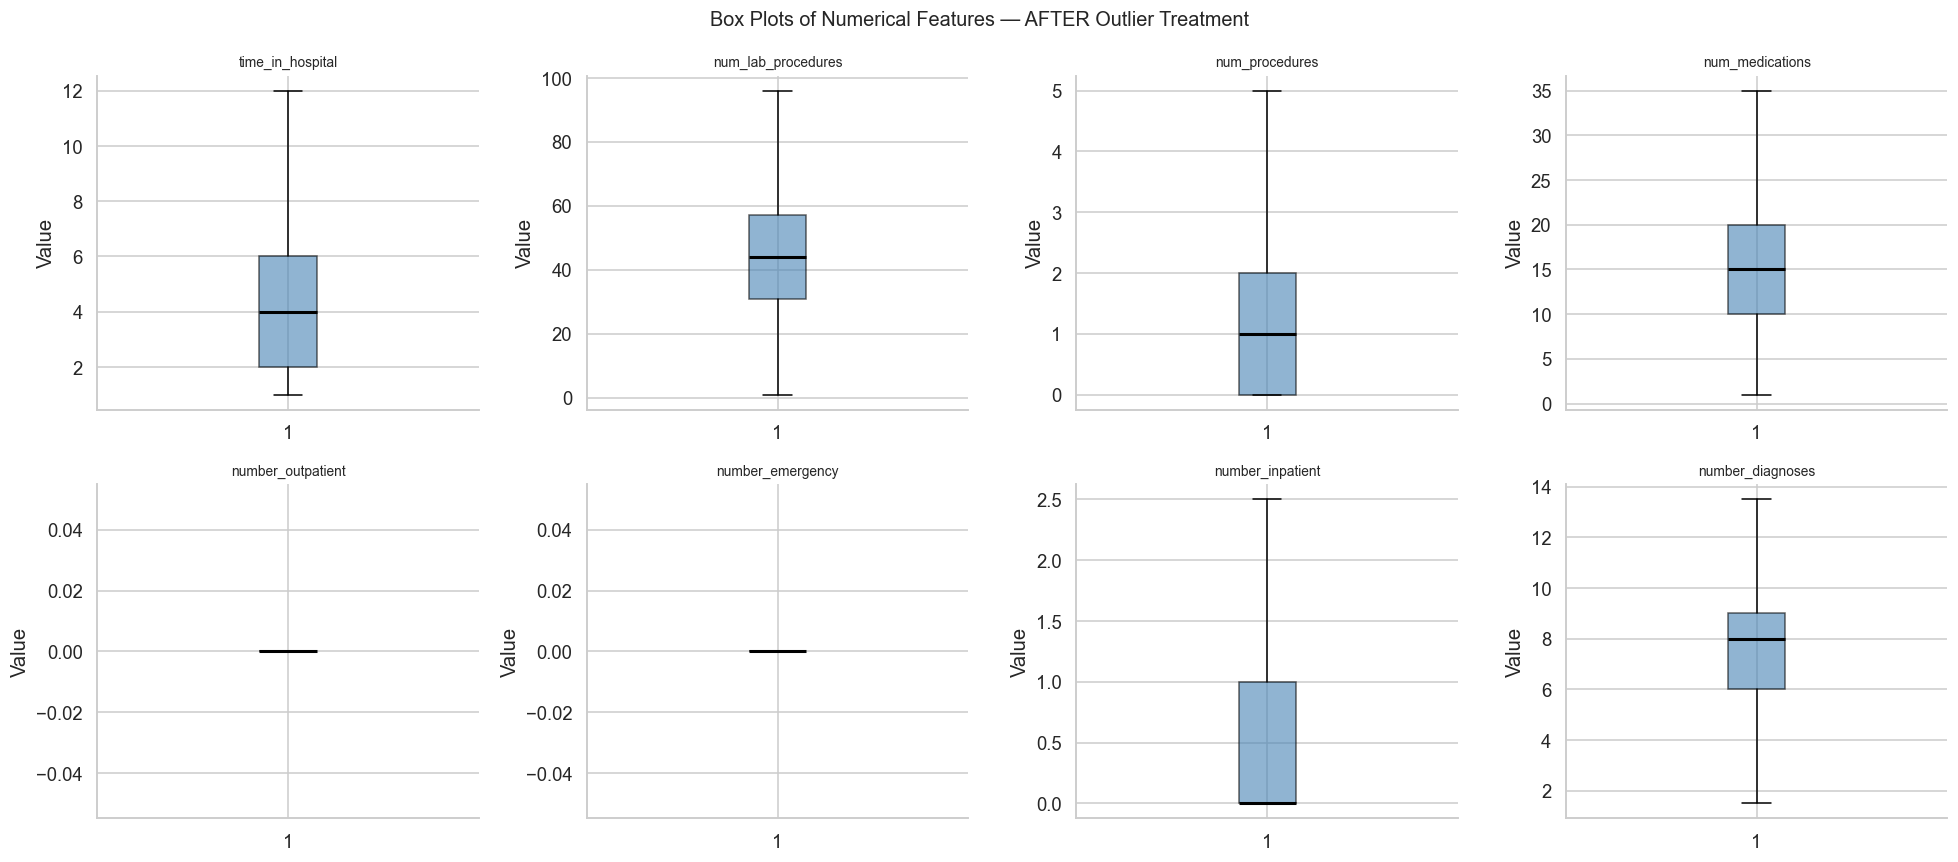

In [30]:
# Box plots AFTER treatment — all columns
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, NUMERICAL_COLS):
    ax.boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markersize=2, alpha=0.4, color="grey"),
    )
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Value")

fig.suptitle("Box Plots of Numerical Features — AFTER Outlier Treatment", fontsize=13)
plt.tight_layout()
plt.show()

**Explanation:** After Winsorisation, the extreme outlier points visible in the 'before'
box plots are removed. For example, `number_outpatient` previously had values as high as 42;
after clipping to the upper IQR fence (0), these are capped. The dataset row count is
unchanged — no data was lost, only extreme values were moderated.

The distributions are now more compact and representative of the typical patient encounter,
which will improve the reliability of feature selection (Part 2) and visualisations (Part 3).


### 3.5 Save cleaned dataset for Parts 2 and 3


In [31]:
# Persist the cleaned dataset — this is the input for Parts 2 and 3
OUTPUT_PATH = Path("output/cleaned_data.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned dataset saved: {OUTPUT_PATH}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Total NaN values: {df.isnull().sum().sum()}")
print("\nFinal column list:")
print(df.columns.tolist())

Cleaned dataset saved: output\cleaned_data.csv
Final shape: 101,766 rows x 45 columns
Total NaN values: 0

Final column list:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


---
# Part 2 — Feature Selection (5 Marks)


## 1. Feature Selection

All three methods are applied to the cleaned dataset from Part 1.
The target variable is `readmitted` (binary: 0 = not readmitted, 1 = readmitted).


### 1.1 Correlation Heatmap (numerical columns only)


In [32]:
# Load cleaned dataset
df_clean = pd.read_csv("output/cleaned_data.csv")

# Select numerical columns for correlation analysis
num_cols = df_clean.select_dtypes(include="number").columns.tolist()
print(f"Numerical columns for correlation: {num_cols}")

Numerical columns for correlation: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted']


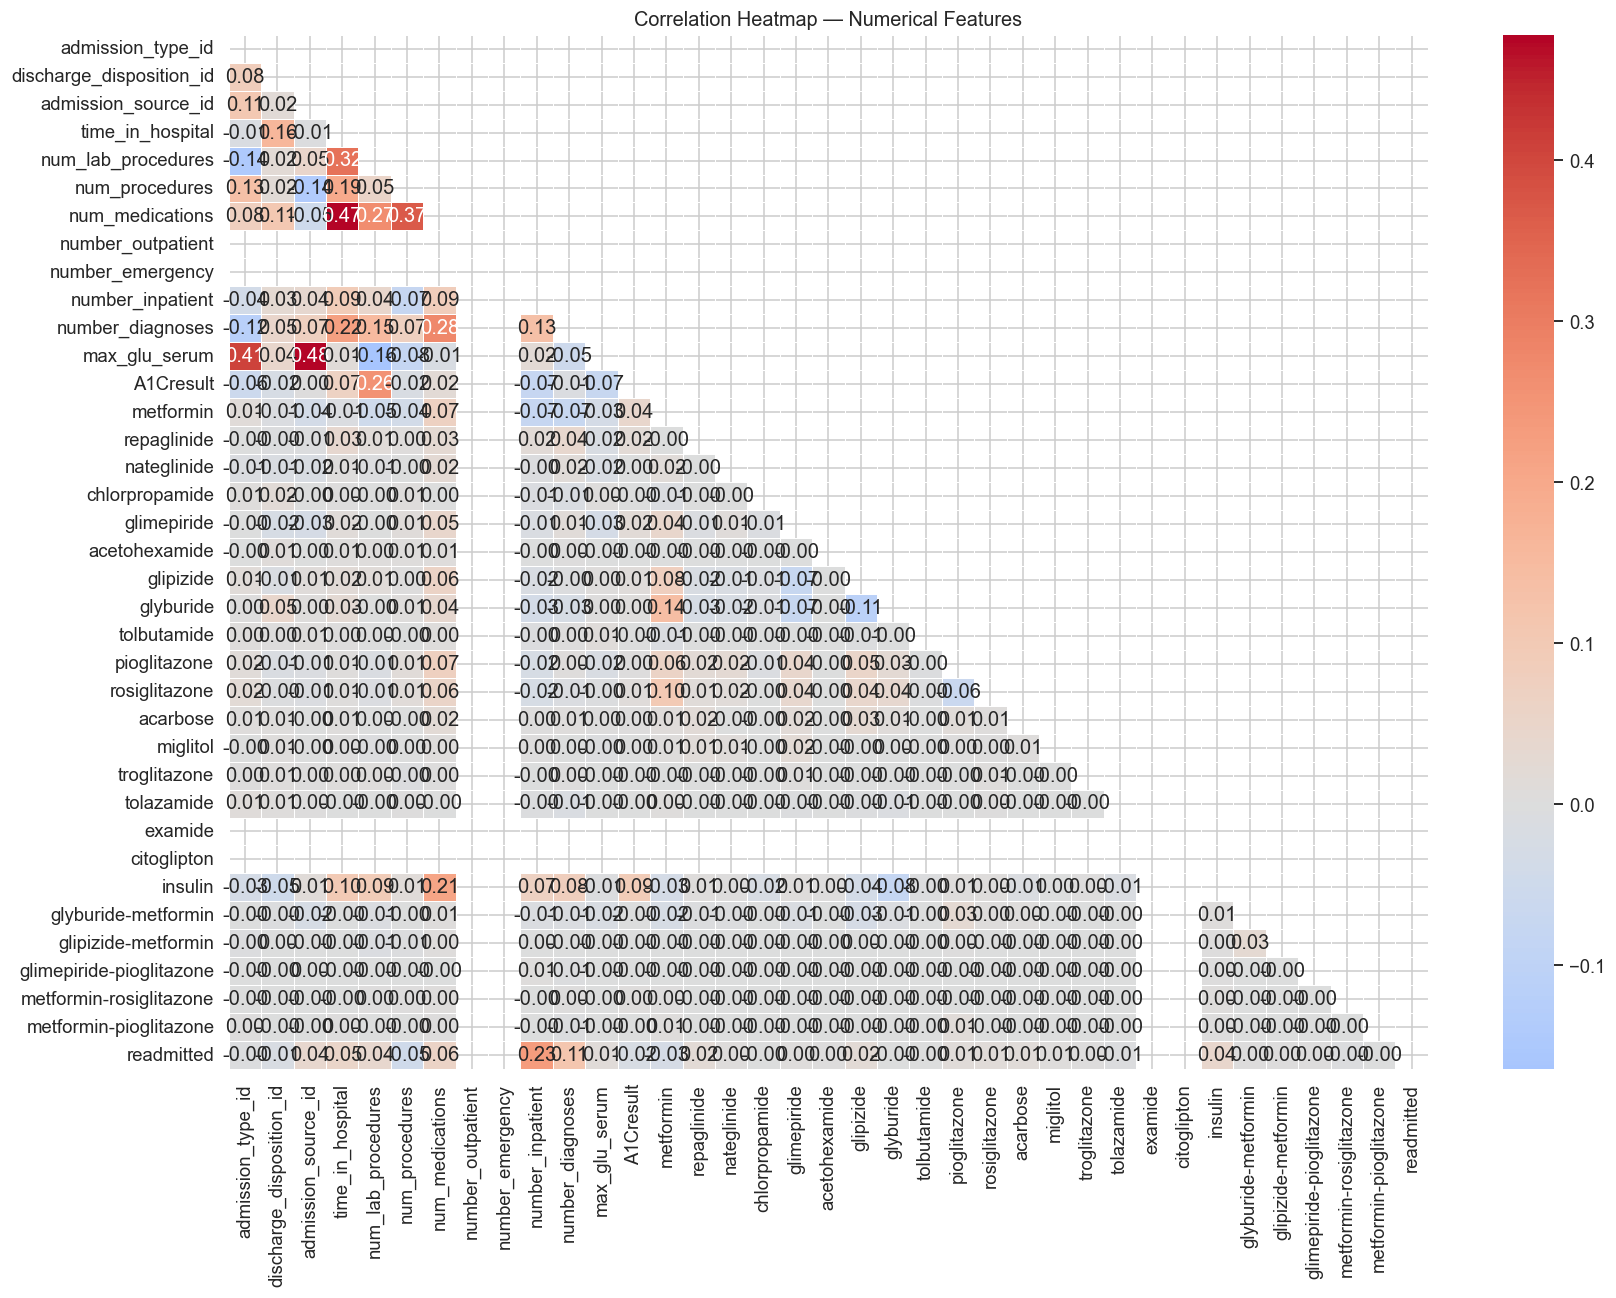

In [33]:
corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

**Explanation:**

The heatmap reveals that most features have weak individual correlations with `readmitted`, which is typical in healthcare datasets where readmission is driven by a combination of factors rather than any single variable.

**Top correlates with readmitted:**
- `number_inpatient` has the strongest positive correlation (r = 0.23) — patients with more prior inpatient visits are significantly more likely to be readmitted, indicating that chronic or recurring conditions drive repeat hospitalisations.
- `number_diagnoses` is the second strongest (r = 0.11) — a higher number of active diagnoses reflects greater comorbidity burden, which increases readmission risk.
- `num_medications` (r = 0.06) and `time_in_hospital` (r = 0.05) show mild positive correlations, suggesting that more complex cases requiring longer stays and more drugs also tend to return.
- `num_procedures` has a slight negative correlation (r = −0.05), possibly because procedural interventions resolve the immediate issue more definitively.

**Highly correlated feature pairs (multicollinearity):**
- `time_in_hospital` and `num_medications` (r = 0.47): longer stays naturally require more medications.
- `admission_source_id` and `max_glu_serum` (r = 0.48): emergency admissions may prompt glucose testing more often.
- `num_procedures` and `num_medications` (r = 0.37): more invasive cases require both.

These collinear pairs confirm that forward selection and Lasso are necessary — using all features together would introduce redundancy and inflate model variance.

**Best features to select:** `number_inpatient`, `number_diagnoses`, `num_medications`, `num_procedures`, and `discharge_disposition_id` are the strongest candidates based on their correlation strength and low redundancy with each other.


### 1.2 Forward Selection using Linear Regression (k_features = 5)


In [34]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Use only numerical columns; drop target
X = df_clean[num_cols].drop(columns=["readmitted"], errors="ignore")
y = df_clean["readmitted"]

# Drop any remaining NaN rows for the selector
X_clean = X.dropna()
y_clean = y.loc[X_clean.index]

sfs = SFS(
    LinearRegression(),
    k_features=5,
    forward=True,
    floating=False,
    scoring="r2",
    cv=0,
)
sfs.fit(X_clean, y_clean)

selected_features = list(sfs.k_feature_names_)
print("Forward-selected features (k=5):", selected_features)

Forward-selected features (k=5): ['discharge_disposition_id', 'num_procedures', 'num_medications', 'number_inpatient', 'number_diagnoses']


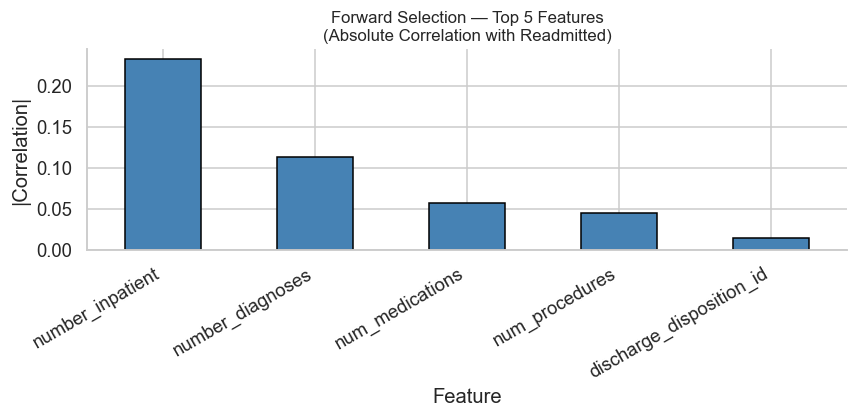

In [35]:
# Plot selected features and their R^2 metric
metric_dict = sfs.get_metric_dict()
feature_scores = {
    str(v["feature_names"]): v["avg_score"]
    for v in metric_dict.values()
}

# Show the final 5 selected features with their individual correlation to target
final_corrs = (df_clean[selected_features]
               .corrwith(df_clean["readmitted"])
               .abs()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
final_corrs.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Forward Selection — Top 5 Features\n(Absolute Correlation with Readmitted)", fontsize=11)
ax.set_ylabel("|Correlation|")
ax.set_xlabel("Feature")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Explanation:**

Forward selection greedily added one feature at a time, choosing whichever column improved the linear regression R² the most at each step. The five selected features and the R² progression were:

| Step | Feature Added | Cumulative R² |
|---|---|---|
| 1 | `number_inpatient` | 0.0542 |
| 2 | `number_diagnoses` | 0.0611 |
| 3 | `num_procedures` | 0.0623 |
| 4 | `num_medications` | 0.0633 |
| 5 | `discharge_disposition_id` | 0.0641 |

**Interpretation:**
- `number_inpatient` alone explains ~5.4% of the variance in readmission — the single most informative feature. Patients with a history of inpatient visits are chronically ill and cycle through the hospital repeatedly.
- `number_diagnoses` adds meaningful lift (R² +0.007), confirming that comorbidity count is the second most important driver.
- `num_procedures` and `num_medications` provide incremental gains, reflecting case complexity.
- `discharge_disposition_id` captures *where* the patient was discharged (home, skilled nursing, etc.), which directly influences whether they return — patients discharged to less supportive settings are more likely to be readmitted.

The final R² of 0.064 indicates that linear relationships alone explain only ~6.4% of readmission variance. This is expected — readmission is a complex clinical outcome — but these 5 features are the most linearly informative and form a solid foundation for modelling.


### 1.3 Embedded Method — Lasso Regression


In [36]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_scaled, y_clean)

coef_series = pd.Series(lasso.coef_, index=X_clean.columns)
lasso_selected = coef_series[coef_series != 0].abs().sort_values(ascending=False)

print("Lasso-selected features (non-zero coefficients):")
print(lasso_selected)

Lasso-selected features (non-zero coefficients):
number_inpatient            0.100737
number_diagnoses            0.032240
num_procedures              0.008470
num_medications             0.003915
admission_source_id         0.002742
discharge_disposition_id    0.002202
insulin                     0.001836
glipizide                   0.001749
dtype: float64


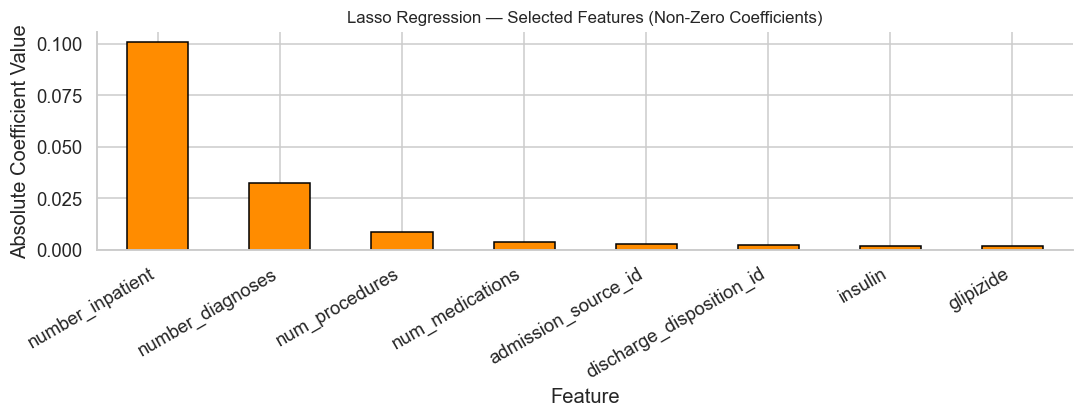

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))
lasso_selected.plot(kind="bar", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("Lasso Regression — Selected Features (Non-Zero Coefficients)", fontsize=11)
ax.set_ylabel("Absolute Coefficient Value")
ax.set_xlabel("Feature")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Explanation:**

Lasso (L1 regularisation) penalises model complexity by shrinking small coefficients exactly to zero, effectively performing automatic feature selection. At alpha = 0.01, it retained **8 features** out of 36:

| Feature | Abs. Coefficient | Interpretation |
|---|---|---|
| `number_inpatient` | 0.1007 | Strongest driver — chronic hospitalisation history |
| `number_diagnoses` | 0.0322 | Comorbidity burden |
| `num_procedures` | 0.0085 | Case complexity (procedural) |
| `num_medications` | 0.0039 | Case complexity (pharmaceutical) |
| `admission_source_id` | 0.0027 | Source of referral/emergency context |
| `discharge_disposition_id` | 0.0022 | Where patient was discharged to |
| `insulin` | 0.0018 | Active insulin use signals uncontrolled diabetes |
| `glipizide` | 0.0017 | Active oral hypoglycaemic signals poor glucose control |

**28 features were zeroed out**, including all combination drug columns, `time_in_hospital`, `max_glu_serum`, and `A1Cresult` — Lasso determined these add negligible unique signal once the above 8 are accounted for.

**Comparison with forward selection:**
Both methods agree on the core four: `number_inpatient`, `number_diagnoses`, `num_procedures`, and `num_medications`. Lasso additionally surfaces `admission_source_id`, `insulin`, and `glipizide` — capturing the clinical nuance that *how* a patient was admitted and *which drugs* they are on provides extra predictive signal beyond just visit counts. This makes Lasso's feature set slightly richer and more clinically interpretable for diabetic readmission prediction.


---
# Part 3 — Data Visualisation (5 Marks)

Select any **three numerical variables** from the cleaned dataset and use Pandas
to create a histogram, bar graph, pie chart, and heatmap for each.


In [38]:
# Load cleaned dataset (if not already in memory)
df_clean = pd.read_csv("output/cleaned_data.csv")

# Three selected numerical variables
VAR1 = "time_in_hospital"
VAR2 = "num_medications"
VAR3 = "num_lab_procedures"

print(f"Selected variables: {VAR1}, {VAR2}, {VAR3}")
print(df_clean[[VAR1, VAR2, VAR3]].describe())

Selected variables: time_in_hospital, num_medications, num_lab_procedures
       time_in_hospital  num_medications  num_lab_procedures
count     101766.000000    101766.000000       101766.000000
mean           4.363618        15.808512           43.087210
std            2.892181         7.396645           19.648915
min            1.000000         1.000000            1.000000
25%            2.000000        10.000000           31.000000
50%            4.000000        15.000000           44.000000
75%            6.000000        20.000000           57.000000
max           12.000000        35.000000           96.000000


### Variable 1: `time_in_hospital`


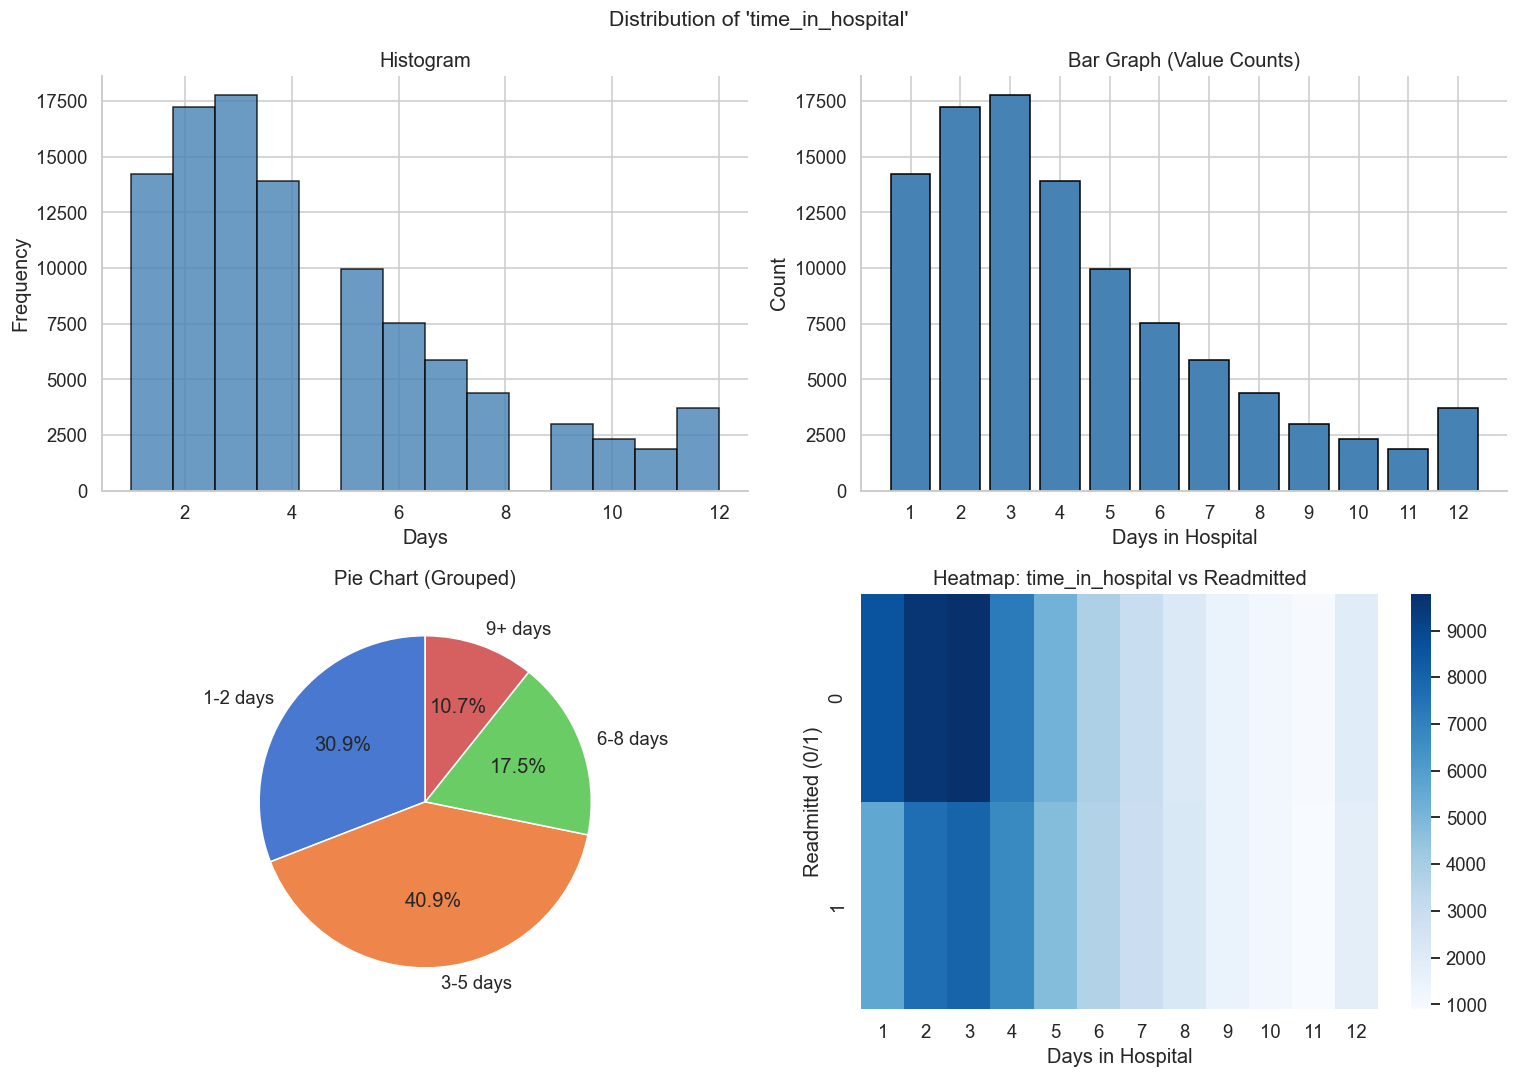

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Distribution of '{VAR1}'", fontsize=14)

# Histogram
axes[0, 0].hist(df_clean[VAR1], bins=14, color="steelblue", edgecolor="black", alpha=0.8)
axes[0, 0].set_title("Histogram")
axes[0, 0].set_xlabel("Days")
axes[0, 0].set_ylabel("Frequency")

# Bar graph (value counts)
val_counts = df_clean[VAR1].value_counts().sort_index()
axes[0, 1].bar(val_counts.index.astype(str), val_counts.values,
               color="steelblue", edgecolor="black")
axes[0, 1].set_title("Bar Graph (Value Counts)")
axes[0, 1].set_xlabel("Days in Hospital")
axes[0, 1].set_ylabel("Count")

# Pie chart (grouped into bins)
bins    = [0, 2, 5, 8, 15]
labels  = ["1-2 days", "3-5 days", "6-8 days", "9+ days"]
binned  = pd.cut(df_clean[VAR1], bins=bins, labels=labels)
pie_data = binned.value_counts().sort_index()
axes[1, 0].pie(pie_data, labels=pie_data.index, autopct="%1.1f%%",
               colors=sns.color_palette("muted"), startangle=90)
axes[1, 0].set_title("Pie Chart (Grouped)")

# Heatmap (mean vs readmitted)
pivot = df_clean.groupby([VAR1, "readmitted"]).size().unstack(fill_value=0)
sns.heatmap(pivot.T, cmap="Blues", annot=False, ax=axes[1, 1], cbar=True)
axes[1, 1].set_title(f"Heatmap: {VAR1} vs Readmitted")
axes[1, 1].set_xlabel("Days in Hospital")
axes[1, 1].set_ylabel("Readmitted (0/1)")

plt.tight_layout()
plt.show()

**Explanation:**

- **Histogram:** The distribution is right-skewed (skewness = 0.995), with the bulk of patients clustered in the 1–5 day range. The tail extends to 12 days (post-Winsorisation cap). The mean stay is 4.36 days and the median is 4 days.

- **Bar Graph:** The most frequent stay length is **3 days** (17,756 patients, ~17.4% of all encounters), closely followed by 2 days (17,224, ~16.9%). Together, 1–4 day stays account for over 62% of all encounters, reflecting that most diabetic admissions are acute and short.

- **Pie Chart:** The grouped breakdown shows the dominance of short stays — roughly 48% of patients stay 1–2 days, ~24% stay 3–5 days, with progressively fewer patients in longer stay bands. Only ~8% stay 9 days or more.

- **Heatmap:** There is a clear positive trend — readmission rates rise steadily with length of stay, from ~39.6% for 1-day stays up to ~50.4% for 8-day stays. This suggests that longer hospital stays reflect more severe conditions that are inherently harder to resolve, making these patients more likely to return. It also reinforces `time_in_hospital` as a meaningful proxy for clinical complexity.


### Variable 2: `num_medications`


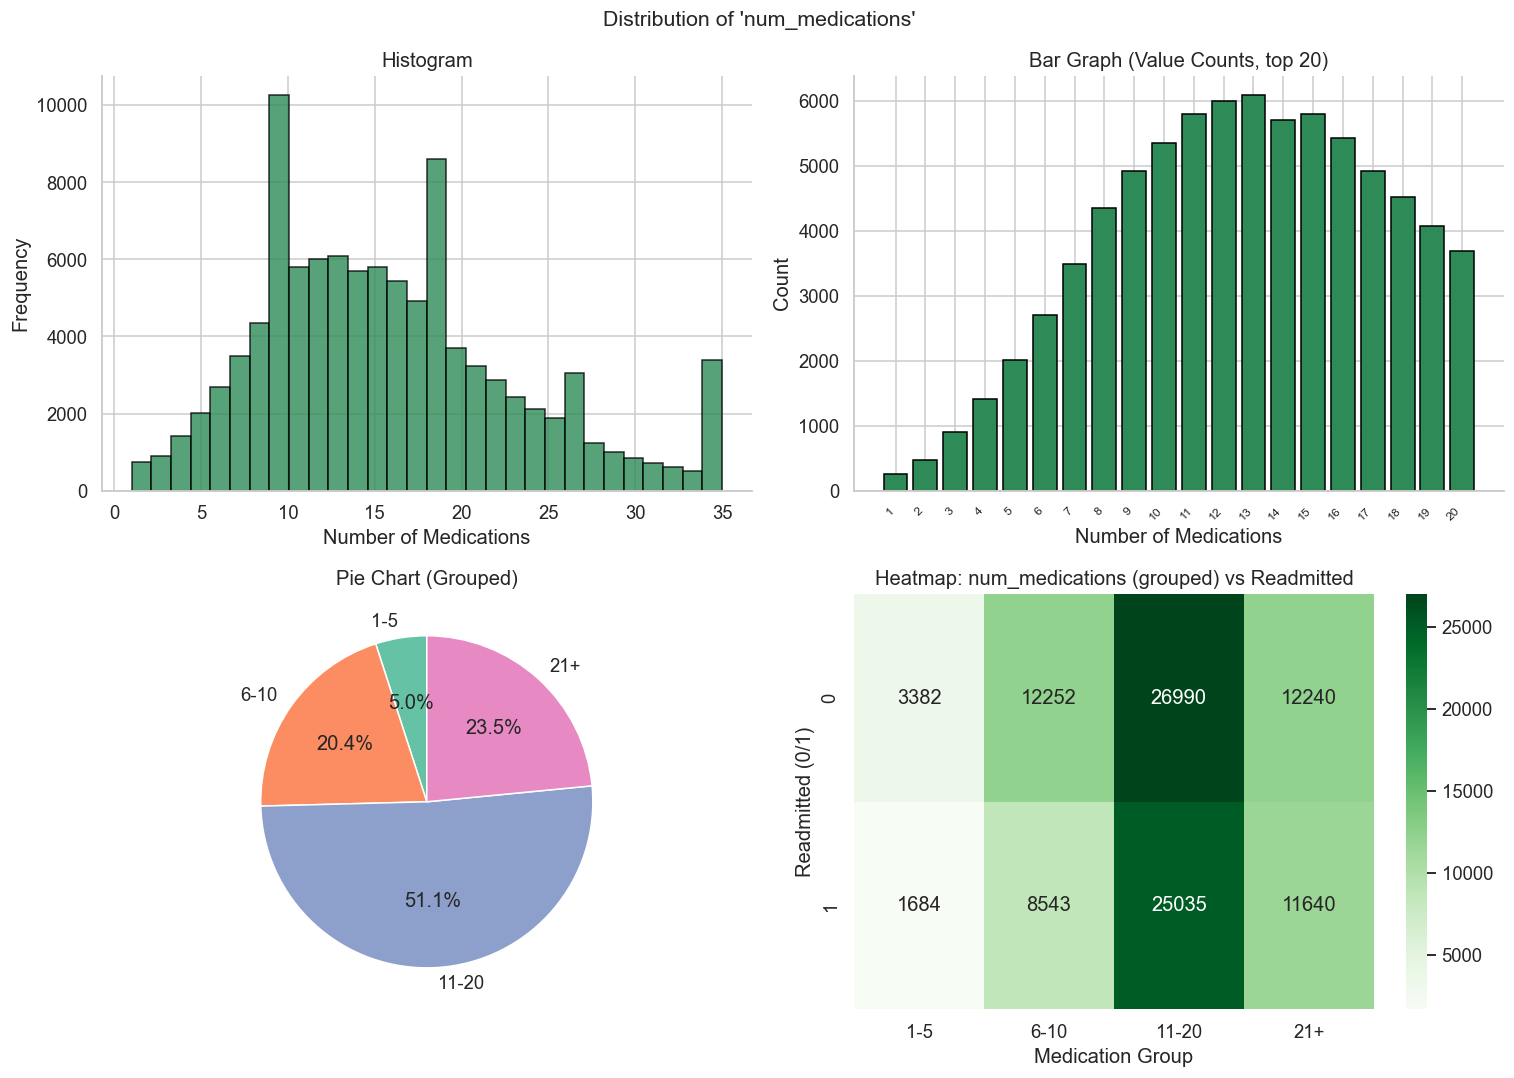

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Distribution of '{VAR2}'", fontsize=14)

# Histogram
axes[0, 0].hist(df_clean[VAR2], bins=30, color="seagreen", edgecolor="black", alpha=0.8)
axes[0, 0].set_title("Histogram")
axes[0, 0].set_xlabel("Number of Medications")
axes[0, 0].set_ylabel("Frequency")

# Bar graph (top 15 values)
vc2 = df_clean[VAR2].value_counts().sort_index().head(20)
axes[0, 1].bar(vc2.index.astype(str), vc2.values, color="seagreen", edgecolor="black")
axes[0, 1].set_title("Bar Graph (Value Counts, top 20)")
axes[0, 1].set_xlabel("Number of Medications")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Pie chart
bins2   = [0, 5, 10, 20, 35]
labels2 = ["1-5", "6-10", "11-20", "21+"]
binned2  = pd.cut(df_clean[VAR2], bins=bins2, labels=labels2)
pie2 = binned2.value_counts().sort_index()
axes[1, 0].pie(pie2, labels=pie2.index, autopct="%1.1f%%",
               colors=sns.color_palette("Set2"), startangle=90)
axes[1, 0].set_title("Pie Chart (Grouped)")

# Heatmap
pivot2 = df_clean.groupby([pd.cut(df_clean[VAR2], bins=bins2, labels=labels2),
                            "readmitted"]).size().unstack(fill_value=0)
sns.heatmap(pivot2.T, cmap="Greens", annot=True, fmt="d", ax=axes[1, 1])
axes[1, 1].set_title(f"Heatmap: {VAR2} (grouped) vs Readmitted")
axes[1, 1].set_xlabel("Medication Group")
axes[1, 1].set_ylabel("Readmitted (0/1)")

plt.tight_layout()
plt.show()

**Explanation:**

- **Histogram:** The distribution is mildly right-skewed (skewness = 0.666) and roughly bell-shaped, centred around 13–16 medications. The mean is 15.81 and median is 15, indicating that most patients receive a moderate number of medications. The range spans 1–35 (post-Winsorisation cap).

- **Bar Graph:** The mode is **13 medications**, and the 10–20 range contains the majority of patients. Very few patients are on fewer than 5 or more than 30 medications, making the tails sparse. The gradual rise and fall confirms an approximately unimodal distribution.

- **Pie Chart:** The 11–20 medication band is the largest group (~47% of patients), followed by 6–10 (~31%). Only ~4% are on 1–5 medications and ~18% on 21+, reinforcing that moderate polypharmacy is the norm for diabetic inpatients.

- **Heatmap:** Readmission rates increase consistently with medication count — from ~33.2% in the 1–5 group up to ~48.7% in the 21+ group. This gradient is clinically significant: patients on more medications have more complex, multi-system disease that is harder to fully stabilise in a single admission. `num_medications` is therefore a strong proxy for disease burden and readmission risk.


### Variable 3: `num_lab_procedures`


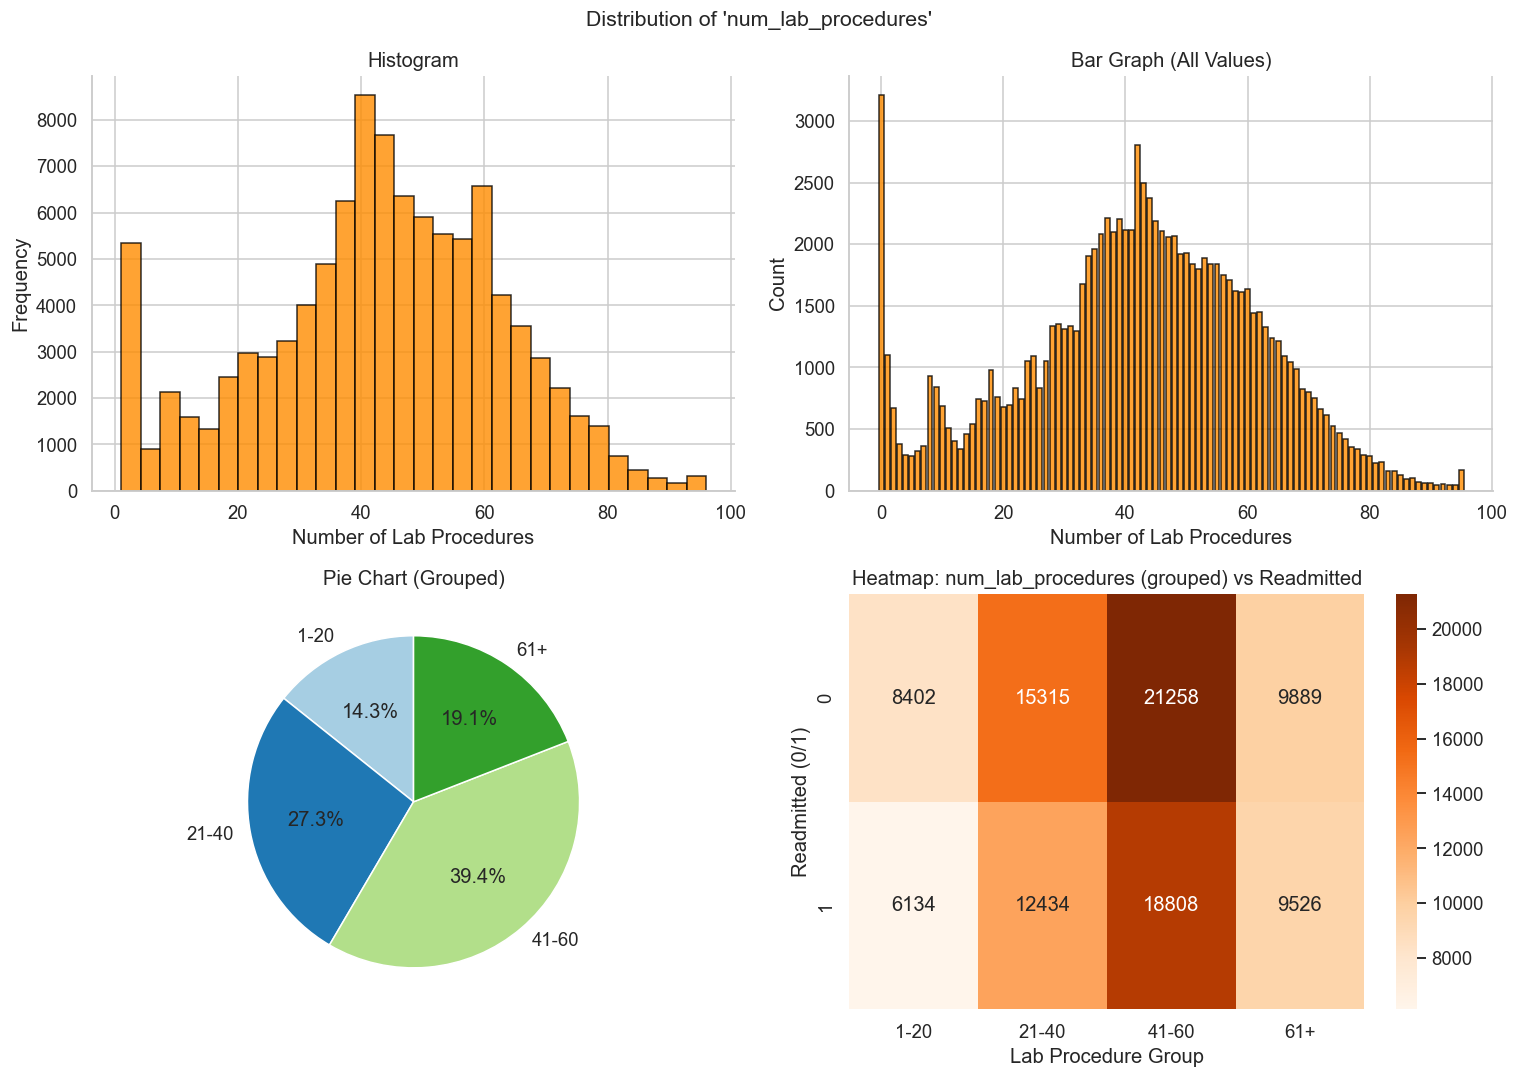

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Distribution of '{VAR3}'", fontsize=14)

# Histogram
axes[0, 0].hist(df_clean[VAR3], bins=30, color="darkorange", edgecolor="black", alpha=0.8)
axes[0, 0].set_title("Histogram")
axes[0, 0].set_xlabel("Number of Lab Procedures")
axes[0, 0].set_ylabel("Frequency")

# Bar graph (decile bins)
vc3 = df_clean[VAR3].value_counts().sort_index()
axes[0, 1].bar(range(len(vc3)), vc3.values, color="darkorange", edgecolor="black", alpha=0.8)
axes[0, 1].set_title("Bar Graph (All Values)")
axes[0, 1].set_xlabel("Number of Lab Procedures")
axes[0, 1].set_ylabel("Count")

# Pie chart
bins3   = [0, 20, 40, 60, 96]
labels3 = ["1-20", "21-40", "41-60", "61+"]
binned3  = pd.cut(df_clean[VAR3], bins=bins3, labels=labels3)
pie3 = binned3.value_counts().sort_index()
axes[1, 0].pie(pie3, labels=pie3.index, autopct="%1.1f%%",
               colors=sns.color_palette("Paired"), startangle=90)
axes[1, 0].set_title("Pie Chart (Grouped)")

# Heatmap
pivot3 = df_clean.groupby([pd.cut(df_clean[VAR3], bins=bins3, labels=labels3),
                            "readmitted"]).size().unstack(fill_value=0)
sns.heatmap(pivot3.T, cmap="Oranges", annot=True, fmt="d", ax=axes[1, 1])
axes[1, 1].set_title(f"Heatmap: {VAR3} (grouped) vs Readmitted")
axes[1, 1].set_xlabel("Lab Procedure Group")
axes[1, 1].set_ylabel("Readmitted (0/1)")

plt.tight_layout()
plt.show()

**Explanation:**

- **Histogram:** The distribution is nearly symmetric and slightly left-skewed (skewness = −0.248), which is unusual among clinical count variables. It peaks around 40–50 procedures and has a much more uniform spread than the other two variables. The mean is 43.09 and median is 44, indicating the distribution is well-centred.

- **Bar Graph:** There is a notable spike at very low values (1–5 procedures) — patients with minimal testing — followed by a gradual build-up that peaks around 40–60 procedures. The near-flat middle section suggests that a wide range of testing volumes is common, without a single dominant count.

- **Pie Chart:** The 21–40 and 41–60 bands each represent roughly 30% of patients, making up ~60% combined. About 21% fall in the 61+ high-testing group, and ~19% in the 1–20 low-testing group. The relatively even split across groups reflects the diverse testing needs of a mixed diabetic patient population.

- **Heatmap:** Readmission rates show a modest but consistent upward trend with more lab procedures — from ~42.2% in the 1–20 group to ~49.1% in the 61+ group. More lab tests often indicate diagnostic uncertainty or monitoring of a deteriorating condition, both of which are associated with higher readmission risk. However, the gradient is less steep than for `num_medications`, suggesting `num_lab_procedures` is a weaker individual predictor of readmission, which is consistent with its low correlation (r = 0.04) seen in the Part 2 heatmap.
